In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
import json

# **Understanding the Data**


## Loading and Exploring the Data

In [92]:
## Loading and Exploring the Data
col_datatypes = {
    "Report Number": str,
    "Local Case Number": str, 
    "Agency Name": str,
    "ACRS Report Type": str,
    "Crash Date/Time": str, 
    "Route Type": str, 
    "Road Name": str, 
    "Cross-Street Name": str, 
    "Off-Road Description": str, 
    "Municipality": str, 
    "Related Non-Motorist": str, 
    "Collision Type": str,
    "Weather": str,
    "Surface Condition": str,
    "Light": str,
    "Traffic Control": str,
    "Driver Substance Abuse": str,
    "Non-Motorist Substance Abuse": str,
    "Person ID": str,
    "Driver At Fault": str,
    "Injury Severity": str,
    "Circumstance": str,
    "Driver Distracted By": str,
    "Drivers License State": str,
    "Vehicle ID": str,
    "Vehicle Damage Extent": str,
    "Vehicle First Impact Location": str,
    "Vehicle Body Type": str,
    "Vehicle Movement": str,
    "Vehicle Going Dir": str,
    "Speed Limit": int,
    "Driverless Vehicle": str,
    "Parked Vehicle": str,
    "Vehicle Year": int,
    "Vehicle Make": str,
    "Vehicle Model": str,
    "Latitude": float,
    "Longitude": float,
    "Location": str
}

crash_df = pd.read_csv("Crash_Reporting_-_Drivers_Data.csv", dtype=col_datatypes)
print(crash_df.shape)
display(crash_df.head())

(210736, 39)


,Report Number,Local Case Number,Agency Name,ACRS Report Type,Crash Date/Time,Route Type,Road Name,Cross-Street Name,Off-Road Description,Municipality,...,Vehicle Going Dir,Speed Limit,Driverless Vehicle,Parked Vehicle,Vehicle Year,Vehicle Make,Vehicle Model,Latitude,Longitude,Location
0,MCP3126006X,250037402,MONTGOMERY,Injury Crash,08/21/2025 05:21:00 PM,Maryland (State) Route,NaN,NaN,NaN,NaN,...,Northbound,40,No,No,2013,KIA,SOUL,39.219796,-77.257416,"(39.219796, -77.25741635)"
1,MCP2349001B,250037516,MONTGOMERY,Property Damage Crash,08/22/2025 10:44:00 AM,Interstate (State),EISENHOWER MEMORIAL HWY,NaN,NaN,NaN,...,Northbound,55,No,No,0,NaN,NaN,39.180181,-77.250657,"(39.18018079, -77.25065714)"
2,MCP296500BC,250033157,MONTGOMERY,Property Damage Crash,07/25/2025 11:55:00 AM,Bicycle Route,NaN,NEW HAMPSHIRE AVE (SB/L) NORBECK RD (WB/L) SPE...,NaN,NaN,...,Westbound,40,No,No,2023,LEXUS,RX,39.121219,-76.988905,"(39.12121898, -76.98890509)"
3,MCP2159003K,250037509,MONTGOMERY,Property Damage Crash,08/22/2025 10:36:00 AM,Maryland (State) Route,NaN,NaN,NaN,NaN,...,Southbound,30,No,No,2003,TOYOTA,SIENNA,39.207931,-77.141480,"(39.20793083, -77.1414795)"
4,MCP312900D6,250034573,MONTGOMERY,Property Damage Crash,08/03/2025 02:10:00 PM,NaN,NaN,NaN,Parking Lot Way PARKING LOT OF 2741 UNI...,NaN,...,Not On Roadway,0,No,No,2023,SUBARU,IMPREZA,39.039662,-77.057238,"(39.03966248, -77.05723843)"


## **Parsing and Adjusting the data**

## Converting Datatypes

In [ ]:
### Lets convert the Crash Date/Time data from string to datetime format

crash_df["Crash Date/Time"] = crash_df["Crash Date/Time"].apply()

0         08/21/2025 05:21:00 PM
1         08/22/2025 10:44:00 AM
2         07/25/2025 11:55:00 AM
3         08/22/2025 10:36:00 AM
4         08/03/2025 02:10:00 PM
                   ...          
210731    08/19/2025 09:59:00 AM
210732    08/17/2025 10:00:00 PM
210733    08/13/2025 10:33:00 AM
210734    08/18/2025 09:20:00 AM
210735    08/16/2025 03:30:00 PM
Name: Crash Date/Time, Length: 210736, dtype: object

## Check how unique values vs total values:


In [ ]:
total_entries = crash_df.shape[0]
unique_df = pd.DataFrame()
unique_df["Column Name"] = crash_df.columns
unique_df["Unique Values"] = unique_df["Column Name"].apply(lambda x: crash_df[x].nunique())
unique_df["Total Values"] = unique_df["Column Name"].apply(lambda x: total_entries - crash_df[x].isna().sum())
unique_df["Is Unique"] = unique_df["Unique Values"] == unique_df["Total Values"]
unique_df

,Column Name,Unique Values,Total Values,Is Unique
0,Report Number,118843,210736,False
1,Local Case Number,118729,210736,False
2,Agency Name,10,210736,False
3,ACRS Report Type,3,210736,False
4,Crash Date/Time,115943,210736,False
5,Route Type,19,190097,False
6,Road Name,4789,186385,False
7,Cross-Street Name,7536,170288,False
8,Off-Road Description,13978,19597,False
9,Municipality,20,19126,False


## Let's Graph it!

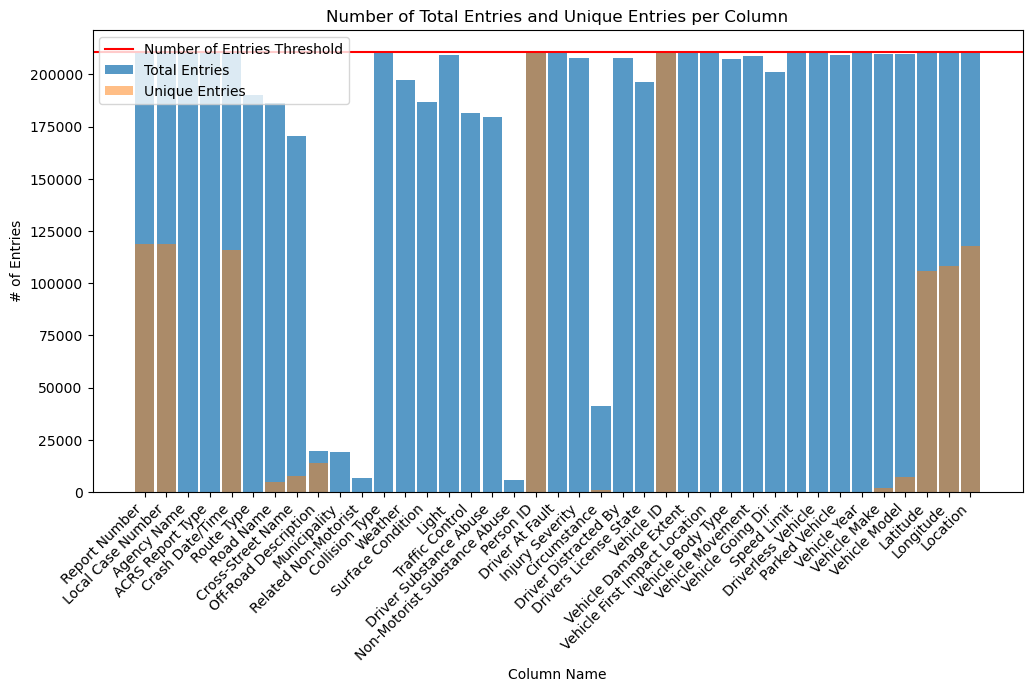

In [91]:
plt.figure(figsize=(12, 6))
plt.bar(unique_df["Column Name"], unique_df["Total Values"], alpha=0.75, width=0.9, label="Total Entries")
plt.bar(unique_df["Column Name"], unique_df["Unique Values"], alpha=0.5, width=0.9, label="Unique Entries")
plt.axhline(total_entries, color='red', label='Number of Entries Threshold')
plt.xticks(rotation=45, ha='right')
plt.xlabel("Column Name")
plt.ylabel("# of Entries")
plt.title("Number of Total Entries and Unique Entries per Column")
plt.legend()
plt.show()

### This information lets us conclude that only the `Vehicle ID` and `Person ID` columns can be used as unique identifiers for our data. Looking at the graph we can also see the density of entries spread accross the data. This leads us to think: How many missing values does each column have and how can we use this information to our advantage.

## Understanding the missing values in our data

In [53]:
na_dict = {}
print("==============[ N/A Statistics ]==============")
print(f"Out of {crash_df.shape[0]} entries, the following number of entries have no values for the columns]\n")
print(f"Total Entries: {crash_df.shape[0]}")
na_dict = crash_df.isna().sum().astype(int).to_dict()
sorted_na = dict(sorted(na_dict.items(), key=lambda x: x[1], reverse=True))
print(json.dumps(sorted_na, indent=2))

==============[ N/A Statistics ]==============
Out of 210736 entries, the following number of entries have no values for the columns]

Total Entries: 210736
{
  "Non-Motorist Substance Abuse": 205003,
  "Related Non-Motorist": 203857,
  "Municipality": 191610,
  "Off-Road Description": 191139,
  "Circumstance": 169751,
  "Cross-Street Name": 40448,
  "Driver Substance Abuse": 31320,
  "Traffic Control": 29088,
  "Road Name": 24351,
  "Surface Condition": 23976,
  "Route Type": 20639,
  "Drivers License State": 14350,
  "Weather": 13356,
  "Vehicle Going Dir": 9525,
  "Vehicle Body Type": 3212,
  "Driver Distracted By": 2856,
  "Injury Severity": 2665,
  "Vehicle Movement": 1679,
  "Parked Vehicle": 1526,
  "Light": 1445,
  "Vehicle Model": 1174,
  "Vehicle Make": 1132,
  "Collision Type": 585,
  "Vehicle Damage Extent": 316,
  "Vehicle First Impact Location": 156,
  "Report Number": 0,
  "Local Case Number": 0,
  "Agency Name": 0,
  "ACRS Report Type": 0,
  "Crash Date/Time": 0,
  "Per

#### From the previous results, we can see that the columns `"Non-Motorist Substance Abuse"`, `"Related Non-Motorists"`, `"Municipality"`, `"Off-Road Description"`, `"Circumstance"`, `"Cross-Street Name"`, `"Driver Substance Abuse"`, and `"Traffic Control"` have over 25,000 missing values in the dataset. These columns should be reconsidered in our EDA as their omission would allow us to consider more datapoints. 